In [5]:
pip install transformers torch tqdm



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached torch-2.12.0-cp310-cp310-win_amd64.whl (122.9 MB)
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


In [1]:
import pandas as pd
import numpy as np
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from tqdm import tqdm

In [3]:
tesla_tweets = pd.read_csv("../data/tesla_tweets.csv")
print(f"Loaded: {len(tesla_tweets)} tweets")
print(tesla_tweets.head())

Loaded: 37422 tweets
         Date                                              Tweet Stock Name  \
0  2022-09-29  Mainstream media has done an amazing job at br...       TSLA   
1  2022-09-29  Tesla delivery estimates are at around 364k fr...       TSLA   
2  2022-09-29  3/ Even if I include 63.0M unvested RSUs as of...       TSLA   
3  2022-09-29  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA   
4  2022-09-29  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA   

  Company Name  
0  Tesla, Inc.  
1  Tesla, Inc.  
2  Tesla, Inc.  
3  Tesla, Inc.  
4  Tesla, Inc.  


In [4]:
print("Loading sentiment model ...")
sentiment_model = pipeline("sentiment-analysis",
                          model = "cardiffnlp/twitter-roberta-base-sentiment-latest",
                          truncation=True,
                          max_length=512)
print("Model loaded!")

Loading sentiment model ...


Loading weights: 100%|████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 12072.96it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [18]:
test_tweets = ["Tesla just broke delivery records! Amazing quarter!",
    "Tesla stock is crashing, very worried about the company",
    "Tesla announced a new model today"]

for tweet in test_tweets:
    result = sentiment_model(tweet)[0]
    print(f"Tweet : {tweet[:50]}")
    print(f"Sentiment: {result['label']} ({result['score']:.2f})\n")

Tweet : Tesla just broke delivery records! Amazing quarter
Sentiment: positive (0.99)

Tweet : Tesla stock is crashing, very worried about the co
Sentiment: negative (0.91)

Tweet : Tesla announced a new model today
Sentiment: positive (0.75)



In [9]:
def get_sentiment(text):
    try:
        text = str(text).strip()
        if len(text)==0:
            return "neutral", 0.5
        result = sentiment_model(text[:512])[0]
        return result['label'].lower(), result['score']

    except:
        return "neutral", 0.5

print("Running sentiment analysis on all tweets ...")


Running sentiment analysis on all tweets ...


In [15]:
tesla_tweets

,Date,Tweet,Stock Name,Company Name
0,2022-09-29,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."
...,...,...,...,...
37417,2021-09-30,Playing in the dirt and #chasingsunsets\n@tesl...,TSLA,"Tesla, Inc."
37418,2021-09-30,I agree with @freshjiva that $TSLA ‘s EV busin...,TSLA,"Tesla, Inc."
37419,2021-09-30,Hold. On. Tight. $TSLA,TSLA,"Tesla, Inc."
37420,2021-09-30,Get ready for a $TSLA _ _ _ _ _ _ Q3 delivery...,TSLA,"Tesla, Inc."


In [6]:
sentiments = []
scores = []


batch_size = 100
for i in tqdm(range(0,len(tesla_tweets),batch_size)):
    batch = tesla_tweets["Tweet"].iloc[i:i+batch_size].tolist()
    batch = [str(t)[:512] for t in batch]

    try:
        results = sentiment_model(batch)
        for r in results:
            sentiments.append(r['label'].lower())
            scores.append(r['score'])

    except:
        for _ in batch:
            sentiments.append("neutral")
            scores.append(0.5)

tesla_tweets["Sentiment"] = sentiments
tesla_tweets["Sentiment_Score"] = scores

print("Done!")
print(tesla_tweets["Sentiment"].value_counts())

100%|██████████████████████████████████████████████████████████████████████████████| 375/375 [1:42:04<00:00, 16.33s/it]

Done!
Sentiment
neutral     15930
positive    14961
negative     6531
Name: count, dtype: int64


In [8]:
def sentiment_to_number(label, score):
    if label == "positive":
        return score
    elif label =="negative":
        return -score
    else:
        return 0

tesla_tweets["Sentiment_Numeric"] = tesla_tweets.apply(
    lambda row:
    sentiment_to_number(row["Sentiment"], row["Sentiment_Score"]), axis = 1)

print(f"Score range: {tesla_tweets['Sentiment_Numeric'].min():.2f} to {tesla_tweets['Sentiment_Numeric'].max():.2f}")
print(f"Average sentiment: {tesla_tweets['Sentiment_Numeric'].mean():.4f}")

Score range: -0.96 to 0.99
Average sentiment: 0.2012


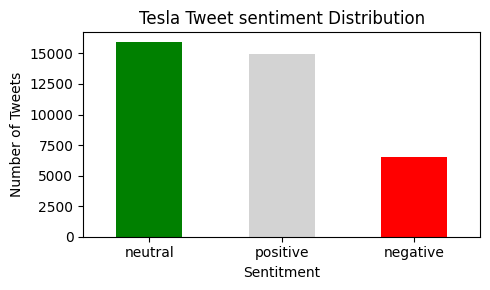

In [13]:
plt.figure(figsize = (5,3))
tesla_tweets["Sentiment"].value_counts().plot(kind="bar", color=["green","lightgray","red"])
plt.title("Tesla Tweet sentiment Distribution")
plt.xlabel("Sentitment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

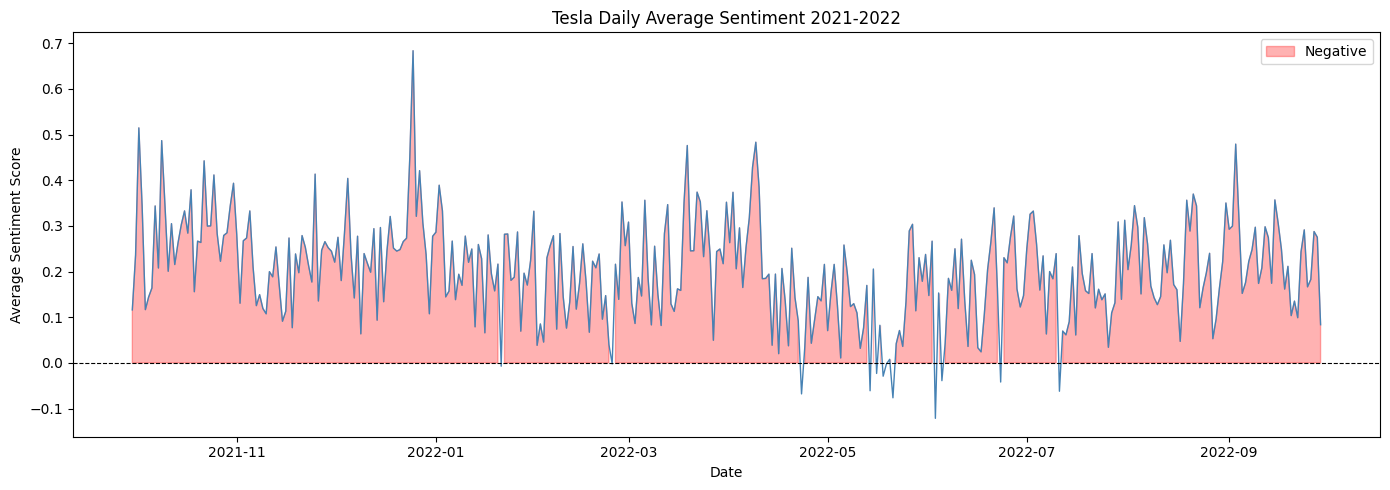

In [14]:
daily_sentiment = tesla_tweets.groupby("Date")["Sentiment_Numeric"].mean().reset_index()
daily_sentiment.columns = ["Date","Avg_Sentiment"]
daily_sentiment["Date"] = pd.to_datetime(daily_sentiment["Date"])

plt.figure(figsize=(14,5))
plt.plot(daily_sentiment['Date'], daily_sentiment['Avg_Sentiment'], color='steelblue',linewidth=1)
plt.axhline(y=0, color="black", linewidth=0.8,linestyle='--')
plt.fill_between(daily_sentiment['Date'], daily_sentiment['Avg_Sentiment'],0, where=daily_sentiment['Avg_Sentiment']>0,color="red",alpha=0.3,label='Negative')
plt.title("Tesla Daily Average Sentiment 2021-2022")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.tight_layout(lt.show()

In [16]:
tesla_tweets.to_csv("../data/tesla_tweets_sentiment.csv", index=False)
daily_sentiment.to_csv("../data/tesla_daily_sentiment.csv", index=False)

print(f"\nSentiement breakdown:")
print(tesla_tweets["Sentiment"].value_counts())
print(f"\nPercentage:")
print(tesla_tweets["Sentiment"].value_counts(normalize=True)*100)


Sentiement breakdown:
Sentiment
neutral     15930
positive    14961
negative     6531
Name: count, dtype: int64

Percentage:
Sentiment
neutral     42.568543
positive    39.979157
negative    17.452301
Name: proportion, dtype: float64
